In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

from einops import rearrange
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset

import overcomplete
from overcomplete.visualization import show
from overcomplete.sae import TopKSAE, train_sae as train_sae_overcomplete

In [2]:
# Configuration
data_dir = Path("../data/processed/")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Load spectrograms and activations (both real and fake)
images_real = np.load(data_dir / "X_spectograms_real.npy")
images_fake = np.load(data_dir / "X_spectograms_fake.npy")
Activations_real = torch.from_numpy(np.load(data_dir / "intermediate_activations_conv2d_2_real.npy")).float().to(device)
Activations_fake = torch.from_numpy(np.load(data_dir / "intermediate_activations_conv2d_2_fake.npy")).float().to(device)

print(f"Real spectrograms shape: {images_real.shape}")
print(f"Fake spectrograms shape: {images_fake.shape}")
print(f"Real activations shape: {Activations_real.shape}")
print(f"Fake activations shape: {Activations_fake.shape}")

Displaying first 5 spectrograms - Real vs Fake:


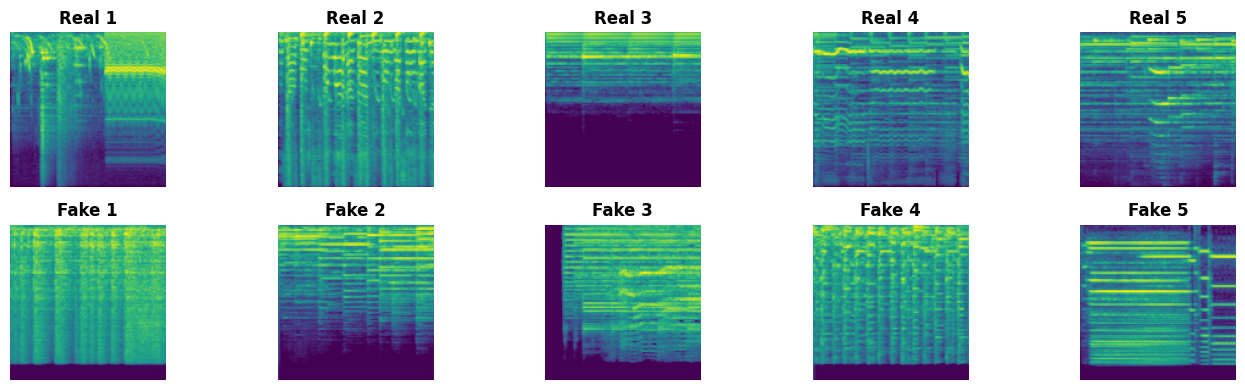

In [10]:
print("Displaying first 5 spectrograms - Real vs Fake:")
plt.figure(figsize=(14, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    show(images_real[i])
    plt.title(f"Real {i+1}", fontweight='bold')
    
    plt.subplot(2, 5, i+6)
    plt.title(f"Fake {i+1}", fontweight='bold')
    show(images_fake[i])
plt.tight_layout()
plt.show()

In [13]:
# Data preparation for SAE training
# Extract dimensions from activations
print(f"Raw activation shapes - Real: {Activations_real.shape}, Fake: {Activations_fake.shape}")

# Handle both 2D and 4D activation tensors
if Activations_real.dim() == 4:
    # If 4D (batch, channels, height, width), flatten to (batch, features)
    batch_size, channels, height, width = Activations_real.shape
    input_dim = channels * height * width
    Activations_real_flat = Activations_real.reshape(Activations_real.shape[0], -1)
    Activations_fake_flat = Activations_fake.reshape(Activations_fake.shape[0], -1)
elif Activations_real.dim() == 2:
    # If already 2D (batch, features)
    batch_size, input_dim = Activations_real.shape
    Activations_real_flat = Activations_real
    Activations_fake_flat = Activations_fake
else:
    raise ValueError(f"Unexpected activation dimensions: {Activations_real.shape}")

print(f"Activation dimensions: {Activations_real.shape}")
print(f"Flattened input dimension: {input_dim}")
print(f"Number of real activation samples: {Activations_real_flat.shape[0]}")
print(f"Number of fake activation samples: {Activations_fake_flat.shape[0]}")

Raw activation shapes - Real: torch.Size([1000, 50176]), Fake: torch.Size([1000, 50176])
Activation dimensions: torch.Size([1000, 50176])
Flattened input dimension: 50176
Number of real activation samples: 1000
Number of fake activation samples: 1000


In [17]:
# Create DataLoaders for training real and fake SAEs
batch_size = 64

# Real SAE DataLoader
real_dataset = TensorDataset(Activations_real_flat)
real_dataloader = DataLoader(real_dataset, batch_size=batch_size, shuffle=True)

# Fake SAE DataLoader
fake_dataset = TensorDataset(Activations_fake_flat)
fake_dataloader = DataLoader(fake_dataset, batch_size=batch_size, shuffle=True)

print(f"Real DataLoader: {len(real_dataloader)} batches")
print(f"Fake DataLoader: {len(fake_dataloader)} batches")

# Initialize TopKSAE models
nb_concepts = 128
top_k = 6

sae_real = TopKSAE(input_dim, nb_concepts=nb_concepts, top_k=top_k, device=device)
sae_fake = TopKSAE(input_dim, nb_concepts=nb_concepts, top_k=top_k, device=device)

print(f"\nReal SAE initialized: input_dim={input_dim}, nb_concepts={nb_concepts}, top_k={top_k}")
print(f"Fake SAE initialized: input_dim={input_dim}, nb_concepts={nb_concepts}, top_k={top_k}")

Real DataLoader: 16 batches
Fake DataLoader: 16 batches

Real SAE initialized: input_dim=50176, nb_concepts=128, top_k=6
Fake SAE initialized: input_dim=50176, nb_concepts=128, top_k=6


In [18]:
# Define criterion function for TopKSAE training
def criterion_sae(x, x_hat, pre_codes, codes, dictionary):
    """
    Criterion for SAE training using TopKSAE from overcomplete library.
    
    Args:
        x: Original input
        x_hat: Reconstructed output
        pre_codes: Pre-activation codes (before top-k)
        codes: Sparse codes (post top-k)
        dictionary: Dictionary weights
    
    Returns:
        MSE loss
    """
    mse = (x - x_hat).square().mean()
    return mse

In [ ]:

# Wrapper function to add tqdm progress for training
def train_sae_overcomplete_with_progress(model, dataloader, criterion, optimizer, nb_epochs, device):
    """
    Wrapper around train_sae_overcomplete that adds epoch progress bars.
    """
    results = {'train_loss': []}
    
    # Create an epoch progress bar
    epoch_progress = tqdm(range(nb_epochs), desc="Training epochs", unit="epoch")
    
    # Manual training loop with progress tracking
    for epoch in epoch_progress:
        model.train()
        epoch_loss = 0.0
        batch_count = 0
        
        # Inner progress bar for batches
        batch_progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{nb_epochs}", leave=False, unit="batch")
        for batch_idx, (x,) in enumerate(batch_progress):
            x = x.to(device)
            
            # Encode to get codes
            pre_codes, codes = model.encode(x)
            # Decode to get reconstruction
            x_hat = model.decode(codes)
            loss = criterion(x, x_hat, pre_codes, codes, model.dictionary)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
            batch_progress.set_postfix({'loss': f'{loss.item():.6f}'})
        
        avg_epoch_loss = epoch_loss / batch_count
        results['train_loss'].append(avg_epoch_loss)
        epoch_progress.set_postfix({'loss': f'{avg_epoch_loss:.6f}'})
    
    return results

In [22]:
# Train SAE on REAL activations
print("=" * 60)
print("TRAINING SAE ON REAL ACTIVATIONS")
print("=" * 60)

optimizer_real = optim.Adam(sae_real.parameters(), lr=5e-4)

real_results = train_sae_overcomplete_with_progress(
    sae_real,
    real_dataloader,
    criterion_sae,
    optimizer_real,
    nb_epochs=20,
    device=device
)

print(f"Real SAE training complete!")

TRAINING SAE ON REAL ACTIVATIONS


Training epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

Training epochs:   0%|          | 0/20 [00:05<?, ?epoch/s]


RuntimeError: The size of tensor a (50176) must match the size of tensor b (128) at non-singleton dimension 1

In [ ]:
# Train SAE on FAKE activations
print("\n" + "=" * 60)
print("TRAINING SAE ON FAKE ACTIVATIONS")
print("=" * 60)

optimizer_fake = optim.Adam(sae_fake.parameters(), lr=5e-4)

fake_results = train_sae_overcomplete_with_progress(
    sae_fake,
    fake_dataloader,
    criterion_sae,
    optimizer_fake,
    nb_epochs=20,
    device=device
)

print(f"Fake SAE training complete!")

In [ ]:
# Compare model performance on test samples
print("=" * 60)
print("COMPARING SAE PERFORMANCE")
print("=" * 60)

sae_real.eval()
sae_fake.eval()

n_samples = 100

with torch.no_grad():
    # Compute reconstruction errors for real activations
    real_recon_real_sae = sae_real.encode(Activations_real_flat[:n_samples])
    x_recon_real_sae = sae_real.decode(real_recon_real_sae[1])  # Use sparse codes
    loss_real_on_real = (Activations_real_flat[:n_samples] - x_recon_real_sae).square().mean(dim=1)
    
    real_recon_fake_sae = sae_fake.encode(Activations_real_flat[:n_samples])
    x_recon_fake_sae = sae_fake.decode(real_recon_fake_sae[1])
    loss_real_on_fake = (Activations_real_flat[:n_samples] - x_recon_fake_sae).square().mean(dim=1)
    
    print(f"Real SAE reconstruction on real activations: {loss_real_on_real.mean():.6f} (±{loss_real_on_real.std():.6f})")
    print(f"Fake SAE reconstruction on real activations: {loss_real_on_fake.mean():.6f} (±{loss_real_on_fake.std():.6f})")
    
    # Compute reconstruction errors for fake activations
    fake_recon_real_sae = sae_real.encode(Activations_fake_flat[:n_samples])
    x_recon_real_sae_fake = sae_real.decode(fake_recon_real_sae[1])
    loss_fake_on_real = (Activations_fake_flat[:n_samples] - x_recon_real_sae_fake).square().mean(dim=1)
    
    fake_recon_fake_sae = sae_fake.encode(Activations_fake_flat[:n_samples])
    x_recon_fake_sae_fake = sae_fake.decode(fake_recon_fake_sae[1])
    loss_fake_on_fake = (Activations_fake_flat[:n_samples] - x_recon_fake_sae_fake).square().mean(dim=1)
    
    print(f"Real SAE reconstruction on fake activations: {loss_fake_on_real.mean():.6f} (±{loss_fake_on_real.std():.6f})")
    print(f"Fake SAE reconstruction on fake activations: {loss_fake_on_fake.mean():.6f} (±{loss_fake_on_fake.std():.6f})")

In [ ]:
# Calculate feature usage statistics
print("=" * 60)
print("FEATURE USAGE ANALYSIS")
print("=" * 60)

with torch.no_grad():
    # Encode all activations to get sparse codes
    _, codes_real = sae_real.encode(Activations_real_flat)
    _, codes_fake = sae_fake.encode(Activations_fake_flat)

# Calculate usage percentages (frequency of non-zero activation)
real_sae_usage = (codes_real > 0).sum(dim=0).float() / codes_real.shape[0] * 100
fake_sae_usage = (codes_fake > 0).sum(dim=0).float() / codes_fake.shape[0] * 100

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real SAE feature usage
sorted_real_idx = torch.argsort(real_sae_usage, descending=True)
axes[0].bar(range(len(real_sae_usage)), real_sae_usage[sorted_real_idx].cpu().numpy(), color='skyblue', edgecolor='navy')
axes[0].set_xlabel('Concept Index (Sorted by Usage)', fontsize=11)
axes[0].set_ylabel('Usage Frequency (%)', fontsize=11)
axes[0].set_title('Real SAE: Feature Usage Across Activations', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Fake SAE feature usage
sorted_fake_idx = torch.argsort(fake_sae_usage, descending=True)
axes[1].bar(range(len(fake_sae_usage)), fake_sae_usage[sorted_fake_idx].cpu().numpy(), color='coral', edgecolor='darkred')
axes[1].set_xlabel('Concept Index (Sorted by Usage)', fontsize=11)
axes[1].set_ylabel('Usage Frequency (%)', fontsize=11)
axes[1].set_title('Fake SAE: Feature Usage Across Activations', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print top usage statistics
print(f"\nTop 5 most used concepts in Real SAE:")
for i in range(5):
    idx = sorted_real_idx[i].item()
    print(f"  Concept {idx:3d} → {real_sae_usage[idx]:.2f}% usage")

print(f"\nTop 5 most used concepts in Fake SAE:")
for i in range(5):
    idx = sorted_fake_idx[i].item()
    print(f"  Concept {idx:3d} → {fake_sae_usage[idx]:.2f}% usage")

In [ ]:
# Analyze latent representations from both SAEs
print("=" * 60)
print("LATENT REPRESENTATION ANALYSIS")
print("=" * 60)

with torch.no_grad():
    # Encode all real and fake activations using TopKSAE
    # encode returns (pre_codes, codes) where codes are sparse codes
    pre_real_by_real, codes_real_by_real = sae_real.encode(Activations_real_flat)
    pre_real_by_fake, codes_real_by_fake = sae_fake.encode(Activations_real_flat)
    pre_fake_by_real, codes_fake_by_real = sae_real.encode(Activations_fake_flat)
    pre_fake_by_fake, codes_fake_by_fake = sae_fake.encode(Activations_fake_flat)

# Compute statistics on sparse codes
print("\nReal SAE latent representations:")
print(f"  Real samples - Mean: {codes_real_by_real.mean(0).abs().mean():.6f}, Std: {codes_real_by_real.std(0).mean():.6f}")
print(f"  Fake samples - Mean: {codes_fake_by_real.mean(0).abs().mean():.6f}, Std: {codes_fake_by_real.std(0).mean():.6f}")

print("\nFake SAE latent representations:")
print(f"  Real samples - Mean: {codes_real_by_fake.mean(0).abs().mean():.6f}, Std: {codes_real_by_fake.std(0).mean():.6f}")
print(f"  Fake samples - Mean: {codes_fake_by_fake.mean(0).abs().mean():.6f}, Std: {codes_fake_by_fake.std(0).mean():.6f}")

# Compute distance between real and fake latent representations
from torch.nn.functional import cosine_similarity

cos_sim_real_sae = cosine_similarity(
    codes_real_by_real.mean(0, keepdim=True),
    codes_fake_by_real.mean(0, keepdim=True)
)
cos_sim_fake_sae = cosine_similarity(
    codes_real_by_fake.mean(0, keepdim=True),
    codes_fake_by_fake.mean(0, keepdim=True)
)

print(f"\nCosine similarity between real/fake latent means:")
print(f"  Real SAE: {cos_sim_real_sae.item():.6f}")
print(f"  Fake SAE: {cos_sim_fake_sae.item():.6f}")

In [ ]:
# Save models for later use
models_dir = Path("../models/")
models_dir.mkdir(exist_ok=True)

torch.save(sae_real.state_dict(), models_dir / "sae_real.pt")
torch.save(sae_fake.state_dict(), models_dir / "sae_fake.pt")

print(f"Models saved:")
print(f"  Real SAE: {models_dir / 'sae_real.pt'}")
print(f"  Fake SAE: {models_dir / 'sae_fake.pt'}")

In [ ]:
# Visualize latent feature statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Real SAE analysis - sparse codes
axes[0, 0].bar(range(codes_real_by_real.shape[1]), codes_real_by_real.mean(0).cpu().numpy(), alpha=0.7, label='Real Data')
axes[0, 0].bar(range(codes_fake_by_real.shape[1]), codes_fake_by_real.mean(0).cpu().numpy(), alpha=0.7, label='Fake Data')
axes[0, 0].set_title('Real SAE: Mean Sparse Codes', fontweight='bold')
axes[0, 0].set_xlabel('Concept Index')
axes[0, 0].set_ylabel('Mean Activation')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Fake SAE analysis - sparse codes
axes[0, 1].bar(range(codes_real_by_fake.shape[1]), codes_real_by_fake.mean(0).cpu().numpy(), alpha=0.7, label='Real Data')
axes[0, 1].bar(range(codes_fake_by_fake.shape[1]), codes_fake_by_fake.mean(0).cpu().numpy(), alpha=0.7, label='Fake Data')
axes[0, 1].set_title('Fake SAE: Mean Sparse Codes', fontweight='bold')
axes[0, 1].set_xlabel('Concept Index')
axes[0, 1].set_ylabel('Mean Activation')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Standard deviation comparison
axes[1, 0].bar(['Real SAE\n(Real)', 'Real SAE\n(Fake)', 'Fake SAE\n(Real)', 'Fake SAE\n(Fake)'],
              [codes_real_by_real.std(0).mean().item(),
               codes_fake_by_real.std(0).mean().item(),
               codes_real_by_fake.std(0).mean().item(),
               codes_fake_by_fake.std(0).mean().item()],
              color=['blue', 'red', 'blue', 'red'], alpha=0.7)
axes[1, 0].set_title('Sparse Codes: Std Dev Comparison', fontweight='bold')
axes[1, 0].set_ylabel('Mean Std Dev')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Sparsity comparison (% zeros in sparse codes)
sparsity = [
    (codes_real_by_real == 0).sum().item() / codes_real_by_real.numel() * 100,
    (codes_fake_by_real == 0).sum().item() / codes_fake_by_real.numel() * 100,
    (codes_real_by_fake == 0).sum().item() / codes_real_by_fake.numel() * 100,
    (codes_fake_by_fake == 0).sum().item() / codes_fake_by_fake.numel() * 100,
]
axes[1, 1].bar(['Real SAE\n(Real)', 'Real SAE\n(Fake)', 'Fake SAE\n(Real)', 'Fake SAE\n(Fake)'],
              sparsity, color=['blue', 'red', 'blue', 'red'], alpha=0.7)
axes[1, 1].set_title('Sparse Codes: Sparsity (% Zeros)', fontweight='bold')
axes[1, 1].set_ylabel('Sparsity (%)')
axes[1, 1].set_ylim([0, 100])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Latent representation analysis complete!")